# 01 · Data, SQL features and leakage validation

## Context & methods
The decision unit is one single-line submission attempt. Current adjudication is separate from intake; only earlier available evidence can enter history. See [methodology](../docs/METHODS.md).

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT))
plt.rcParams.update({'figure.figsize':(10,4.5),'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
summary=pd.read_csv(ROOT/'results/policy_summary.csv')
run=json.loads((ROOT/'results/run_summary.json').read_text())
scored=pd.read_csv(ROOT/'results/scored_claims.csv',dtype={'procedure_code':str})


## Data
24,000 synthetic claim-level demo attempts are calibrated to actual CMS 2023 PSPS office-service summaries. Public aggregates do not contain patient histories. Suppressed cells remain unknown. See [source receipt and transformations](../docs/DATA_SOURCES.md).

In [2]:
bench=pd.read_csv(ROOT/'data/sources/cms_benchmarks.csv',dtype={'procedure_code':str})
display(bench[['procedure_code','submitted_services','allowed_services_derived','denied_services','denied_service_rate','submitted_volume_retained']].round(4))

,procedure_code,submitted_services,allowed_services_derived,denied_services,denied_service_rate,submitted_volume_retained
0,99213,61202507.2,58881038.3,2321468.9,0.0379,0.9720
1,99214,85303526.4,82457611.7,2845914.7,0.0334,0.9784
2,80053,7094028.0,6777967.0,316061.0,0.0446,0.9840
3,93000,10366343.9,9776885.9,589458.0,0.0569,0.9712
4,97110,62291758.8,58268435.3,4023323.5,0.0646,0.9951


### Comparable calibration audit
Compare dollars per unit and service-weighted nonpayable incidence. Claim-level denial incidence is also shown because service counts and submission counts differ. The balanced code mix, exceptions and drift intentionally move the generated distribution away from the source.

,procedure_code,demo_submitted_per_unit,demo_nonpayable_service_rate,demo_nonpayable_attempt_rate,submitted_per_service,denied_service_rate,dollar_difference_pct,denial_difference_pp
0,80053,53.7622,0.0579,0.0458,49.3968,0.0446,0.0884,1.3385
1,93000,74.3337,0.0651,0.0488,67.8065,0.0569,0.0963,0.8262
2,97110,79.1234,0.0601,0.0580,67.7701,0.0646,0.1675,-0.4448
3,99213,191.6150,0.0477,0.0398,178.7169,0.0379,0.0722,0.9787
4,99214,285.2007,0.0466,0.0369,263.8952,0.0334,0.0807,1.3220


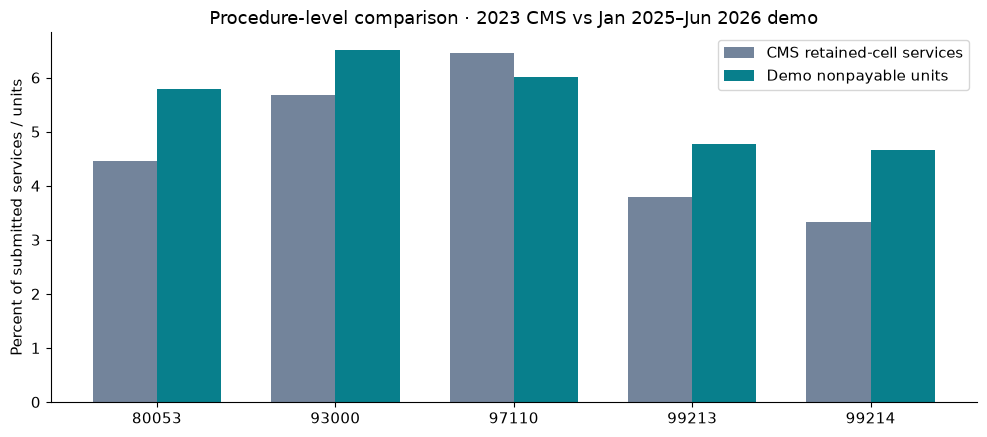

In [3]:
audit=scored.groupby('procedure_code').apply(lambda g: pd.Series({'demo_submitted_per_unit':g.submitted_amount.sum()/g.units.sum(),'demo_nonpayable_service_rate':g.loc[~g.payable,'units'].sum()/g.units.sum(),'demo_nonpayable_attempt_rate':(~g.payable).mean()}),include_groups=False).reset_index()
audit=audit.merge(bench[['procedure_code','submitted_per_service','denied_service_rate']],on='procedure_code')
audit['dollar_difference_pct']=audit.demo_submitted_per_unit/audit.submitted_per_service-1
audit['denial_difference_pp']=100*(audit.demo_nonpayable_service_rate-audit.denied_service_rate)
audit.to_csv(ROOT/'results/calibration_audit.csv',index=False)
display(audit.round(4))
x=np.arange(len(audit)); fig,ax=plt.subplots()
ax.bar(x-.18,audit.denied_service_rate*100,.36,label='CMS retained-cell services',color='#73849b')
ax.bar(x+.18,audit.demo_nonpayable_service_rate*100,.36,label='Demo nonpayable units',color='#087f8c')
ax.set(xticks=x,xticklabels=audit.procedure_code,ylabel='Percent of submitted services / units',title='Procedure-level comparison · 2023 CMS vs Jan 2025–Jun 2026 demo'); ax.legend(); plt.tight_layout(); plt.show()


### SQL lineage
The executable feature query uses CTEs, timestamp RANGE windows and lateral as-of joins. Frequency and amount windows cover 90 days; provider payable history uses outcomes already available from the preceding 180 days. No full-period aggregate is joined back to prior claims.

In [4]:
sql=(ROOT/'sql/02_features.sql').read_text()
print(sql)

SET search_path TO stp;
DROP TABLE IF EXISTS claim_features;
CREATE TABLE claim_features AS
WITH intake AS (
 SELECT c.*,
   (service_date BETWEEN p.coverage_start AND p.coverage_end
      AND coverage_response = 'active') AS coverage_ok,
   (service_date BETWEEN v.enrollment_start AND v.enrollment_end) AS provider_enrolled,
   (submitted_at::date > (service_date + INTERVAL '1 year')::date) AS late_filing,
   EXTRACT(DAY FROM submitted_at-service_date)::integer AS submission_lag_days
 FROM claims c JOIN patients p USING(patient_id) JOIN providers v USING(provider_id)
), history_windows AS (
 SELECT i.*,
   COUNT(*) OVER (PARTITION BY patient_id ORDER BY submitted_at
     RANGE BETWEEN INTERVAL '90 days' PRECEDING AND INTERVAL '1 microsecond' PRECEDING) AS patient_prior_90d,
   COUNT(*) OVER (PARTITION BY provider_id ORDER BY submitted_at
     RANGE BETWEEN INTERVAL '90 days' PRECEDING AND INTERVAL '1 microsecond' PRECEDING) AS provider_prior_90d,
   COUNT(*) OVER pw AS procedure_prior_

### Availability and independent sample checks

In [5]:
from src.database import connect
with connect() as con:
    q=con.execute("SELECT COUNT(*), COUNT(DISTINCT claim_id), COUNT(*) FILTER (WHERE provider_outcome_max_at >= submitted_at OR procedure_history_max_at >= submitted_at OR previous_submission_at >= submitted_at) FROM claim_features").fetchone()
assert q==(24000,24000,0), q
sample=scored.sort_values('claim_id').iloc[12000]
past=scored[(scored.patient_id==sample.patient_id)&(pd.to_datetime(scored.submitted_at)<pd.Timestamp(sample.submitted_at))&(pd.to_datetime(scored.submitted_at)>=pd.Timestamp(sample.submitted_at)-pd.Timedelta(days=90))]
assert len(past)==sample.patient_prior_90d
display(pd.DataFrame([{'claims':q[0],'unique_claims':q[1],'availability_violations':q[2],'independent_sample_prior_count':len(past)}]))
display(scored.groupby('split').agg(n=('claim_id','size'),payable_rate=('payable','mean')))


,claims,unique_claims,availability_violations,independent_sample_prior_count
0,24000,24000,0,1


,n,payable_rate
split,,
calibration,1877,0.958977
holdout,6627,0.942961
maturity_excluded,2451,0.950224
train,11179,0.959656
validation,1866,0.961951


## Takeaways
Feature timestamps satisfy strict availability checks. The automated test suite additionally mutates future dollars, units and outcomes and proves that earlier feature values remain identical; a four-claim fixture tests simultaneous timestamps and label maturity. Maturity exclusions in training and tuning are documented, not silently dropped from the source population.